# Module 4 — Extraction de Caractéristiques NLP

Ce module couvre :
1. Prétraitement textuel (tokenisation, stopwords, stemming/lemmatisation)
2. Vectorisation : BoW, TF-IDF, Word2Vec, FastText
3. Classification : Naive Bayes, Régression Logistique, LinearSVC, Random Forest
4. Bonus : CamemBERT (Sentence Transformers)


## ⚙️ 0. Installations & Imports


In [1]:
# Installations (à exécuter une fois)
import subprocess, sys

packages = [
    'nltk', 'spacy', 'gensim', 'scikit-learn', 'pandas',
    'numpy', 'matplotlib', 'seaborn', 'fasttext-wheel'
]
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

print('Packages installés')

Packages installés


In [2]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

from gensim.models import Word2Vec
import gensim.downloader as api

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
SEED = 42

# Téléchargements NLTK
for resource in ['punkt', 'stopwords', 'wordnet', 'punkt_tab']:
    nltk.download(resource, quiet=True)

print('✅ Imports OK')

✅ Imports OK


## 📂 1. Chargement du Dataset


In [3]:
import os, numpy as np, pandas as pd  # guard — déjà importés en cellule 0

# ─────────────────────────────────────────────────────────────────
# Chargement : full_cleaned.csv (prétraité par Module 1)
#              + Rapport_Collecte depuis le CSV original
# ─────────────────────────────────────────────────────────────────

DATA_PATH     = 'outputs/full_cleaned.csv'       # produit par Module 1
ORIG_CSV_PATH = 'dataset_ProjetML_2026 (1).csv'  # CSV original  ← adapter si besoin
TEXT_COL      = 'Rapport_Collecte'               # colonne texte NLP
LABEL_COL     = 'Categorie'                      # colonne cible

# ── Chargement du fichier prétraité ──────────────────────────────
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Fichier introuvable : {DATA_PATH} — exécuter Module 1 d'abord.")

df = pd.read_csv(DATA_PATH)
print(f'✅ full_cleaned.csv chargé  →  {df.shape}')

# ── Récupération de Rapport_Collecte (absente de full_cleaned) ───
if TEXT_COL not in df.columns:
    if not os.path.exists(ORIG_CSV_PATH):
        raise FileNotFoundError(
            f"CSV original introuvable : {ORIG_CSV_PATH}\n"
            f"Colonnes disponibles dans full_cleaned.csv : {list(df.columns)}"
        )
    df_orig = pd.read_csv(ORIG_CSV_PATH, sep=',', header=0)
    if TEXT_COL not in df_orig.columns:
        raise ValueError(f"Colonne '{TEXT_COL}' introuvable dans {ORIG_CSV_PATH}.\n"
                         f"Colonnes dispo : {list(df_orig.columns)}")

    # Aligner par position : Module 1 a fait dropna(Categorie) + reset_index
    df_orig_aligned = df_orig.dropna(subset=[LABEL_COL]).reset_index(drop=True)
    df[TEXT_COL] = df_orig_aligned[TEXT_COL].values[:len(df)]
    print(f'✅ {TEXT_COL} mergée depuis {ORIG_CSV_PATH}')
else:
    print(f'✅ {TEXT_COL} déjà présente dans full_cleaned.csv')

# ── Garder uniquement les colonnes utiles au NLP ─────────────────
n_avant = len(df)
df = df[[TEXT_COL, LABEL_COL]].dropna().reset_index(drop=True)
print(f'   Lignes retenues : {len(df)} / {n_avant}')
print(f'   Classes : {df[LABEL_COL].value_counts().to_dict()}')
df.head(5)


✅ full_cleaned.csv chargé  →  (9986, 8)
✅ Rapport_Collecte déjà présente dans full_cleaned.csv
   Lignes retenues : 9986 / 9986
   Classes : {'Plastique': 2795, 'Verre': 2586, 'Papier': 2318, 'Métal': 2287}


,Rapport_Collecte,Categorie
0,Lot de papier récupéré dans un site non rensei...,Papier
1,"Lot plastique à l'Usine A. Volume 64.7 L, poid...",Plastique
2,Bris de verre ou contenants en provenance de l...,Verre
3,Feuilles et cartons collectés au Centre de Tri...,Papier
4,Déchet de type papier identifié à l'Usine B. V...,Papier


## 🔤 2. Prétraitement Textuel


In [4]:
# ── Stopwords : français NLTK + domaine métier ────────────────
STOP_FR = set(stopwords.words('french'))

STOP_DOMAIN = {
    'utilisation', 'usage', 'haute', 'haut', 'bon', 'bonne',
    'grand', 'grande', 'type', 'produit', 'matériau', 'matériaux',
    'excellent', 'excellente', 'faible', 'élevé', 'élevée',
    'moyen', 'moyenne', 'application', 'applications',
    'papier', 'papiers',
    'plastique', 'plastiques',
    'verre', 'verres',
    'métal', 'metal', 'métaux', 'metaux',
    'métallique', 'metallique', 'métalliques',
}

ALL_STOPS = STOP_FR | STOP_DOMAIN

# ── Stemmer & Lemmatizer ──────────────────────────────────────
stemmer    = SnowballStemmer('french')
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """Nettoyage de base : minuscules, suppression caractères spéciaux."""
    text = str(text).lower()
    text = re.sub(r'[^a-zàâäéèêëîïôùûüÿç\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text):
    """Tokenisation NLTK."""
    return word_tokenize(text, language='french')

def remove_stopwords(tokens):
    """Suppression des stopwords français + domaine."""
    return [t for t in tokens if t not in ALL_STOPS and len(t) > 2]

def stem_tokens(tokens):
    """Stemming SnowballStemmer."""
    return [stemmer.stem(t) for t in tokens]

def lemmatize_tokens(tokens):
    """Lemmatisation WordNet."""
    return [lemmatizer.lemmatize(t) for t in tokens]

def preprocess(text, method='stem'):
    """Pipeline complet : nettoyage → tokenisation → stopwords → stem/lemma."""
    tokens = tokenize(clean_text(text))
    tokens = remove_stopwords(tokens)
    if method == 'stem':
        tokens = stem_tokens(tokens)
    elif method == 'lemma':
        tokens = lemmatize_tokens(tokens)
    return ' '.join(tokens)

# ── Appliquer aux deux variantes ──────────────────────────────
df['text_stem']  = df[TEXT_COL].apply(lambda x: preprocess(x, method='stem'))
df['text_lemma'] = df[TEXT_COL].apply(lambda x: preprocess(x, method='lemma'))
df['tokens']     = df[TEXT_COL].apply(lambda x: remove_stopwords(tokenize(clean_text(x))))

print('Exemple prétraitement :')
idx = 0
print(f'  Original : {df[TEXT_COL].iloc[idx]}')
print(f'  Stemming : {df["text_stem"].iloc[idx]}')
print(f'  Lemma    : {df["text_lemma"].iloc[idx]}')

Exemple prétraitement :
  Original : Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volume moyen. Matériau souple, non conducteur, aspect très opaque. Bon état général.
  Stemming : lot récuper sit non renseign poid leg volum soupl non conducteur aspect tres opaqu état général
  Lemma    : lot récupéré site non renseigné poids léger volume souple non conducteur aspect très opaque état général


## ✂️ 3. Split Train / Test


In [5]:
le = LabelEncoder()
y  = le.fit_transform(df[LABEL_COL])

X_stem  = df['text_stem'].values
X_lemma = df['text_lemma'].values
tokens  = df['tokens'].tolist()

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_stem, y, test_size=0.2, stratify=y, random_state=SEED
)
X_train_l, X_test_l, _, _ = train_test_split(
    X_lemma, y, test_size=0.2, stratify=y, random_state=SEED
)
tokens_train, tokens_test, _, _ = train_test_split(
    tokens, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f'Train : {len(X_train_s)}  |  Test : {len(X_test_s)}')
print(f'Classes : {list(le.classes_)}')

Train : 7988  |  Test : 1998
Classes : ['Métal', 'Papier', 'Plastique', 'Verre']


## 📦 4. Vectorisation

### 4.1 Bag of Words (BoW)


In [6]:
bow_vec = CountVectorizer(max_features=5000, ngram_range=(1,1))
X_bow_train = bow_vec.fit_transform(X_train_s)
X_bow_test  = bow_vec.transform(X_test_s)

print(f'BoW  → train: {X_bow_train.shape}  |  test: {X_bow_test.shape}')
print(f'Vocabulaire : {len(bow_vec.vocabulary_)} termes')

BoW  → train: (7988, 109)  |  test: (1998, 109)
Vocabulaire : 109 termes


### 4.2 TF-IDF (uni + bigrammes)


In [7]:
tfidf_vec = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),     # unigrammes + bigrammes
    sublinear_tf=True,      # log(1+tf)
    min_df=2
)
X_tfidf_train = tfidf_vec.fit_transform(X_train_s)
X_tfidf_test  = tfidf_vec.transform(X_test_s)

print(f'TF-IDF → train: {X_tfidf_train.shape}  |  test: {X_tfidf_test.shape}')

# Top termes TF-IDF par classe
feature_names = np.array(tfidf_vec.get_feature_names_out())
print('\nTop 5 termes TF-IDF par classe :')
for cls_idx, cls_name in enumerate(le.classes_):
    mask   = y_train == cls_idx
    scores = X_tfidf_train[mask].mean(axis=0).A1
    top5   = feature_names[np.argsort(scores)[-5:][::-1]]
    print(f'  {cls_name:12s}: {list(top5)}')

TF-IDF → train: (7988, 551)  |  test: (1998, 551)

Top 5 termes TF-IDF par classe :
  Métal       : ['conduct', 'conduct rigid', 'rigid', 'valeur', 'marchand']
  Papier      : ['soupl', 'opaqu', 'tres opaqu', 'leg', 'tres']
  Plastique   : ['sem', 'rigid', 'sem rigid', 'rigid non', 'non']
  Verre       : ['rigid', 'lourd', 'tres rigid', 'extrêm rigid', 'extrêm']


### 4.3 Word2Vec (embeddings sémantiques)


In [8]:
# Entraîner Word2Vec sur le corpus d'entraînement
w2v_model = Word2Vec(
    sentences=tokens_train,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,          # Skip-gram
    seed=SEED,
    epochs=50
)

def text_to_w2v(tokens_list, model):
    """Moyenne des vecteurs Word2Vec pour chaque document."""
    vectors = []
    for tokens in tokens_list:
        vecs = [model.wv[t] for t in tokens if t in model.wv]
        vectors.append(np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size))
    return np.array(vectors)

X_w2v_train = text_to_w2v(tokens_train, w2v_model)
X_w2v_test  = text_to_w2v(tokens_test,  w2v_model)

print(f'Word2Vec → train: {X_w2v_train.shape}  |  test: {X_w2v_test.shape}')

# Mots les plus proches (test)
try:
    sample_word = tokens_train[0][0] if tokens_train[0] else 'metal'
    similar = w2v_model.wv.most_similar(sample_word, topn=5)
    print(f'\nMots proches de "{sample_word}" :')
    for word, score in similar:
        print(f'  {word:20s} sim={score:.3f}')
except Exception as e:
    print(f'Pas de mot similaire : {e}')

Word2Vec → train: (7988, 100)  |  test: (1998, 100)

Mots proches de "recyclable" :
  lisse                sim=0.751
  surface              sim=0.394
  marchande            sim=0.390
  prix                 sim=0.387
  ferraille            sim=0.379


### 4.4 FastText (robustesse aux OOV et fautes)


In [9]:
try:
    import fasttext
    FASTTEXT_AVAILABLE = True
except ImportError:
    FASTTEXT_AVAILABLE = False
    print('FastText non disponible — utilisation de Gensim FastText')

# ── Gensim FastText (toujours disponible) ────────────────────
from gensim.models import FastText as GensimFastText

ft_model = GensimFastText(
    sentences=tokens_train,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    seed=SEED,
    epochs=50
)

def text_to_ft(tokens_list, model):
    """Moyenne des vecteurs FastText (gère les OOV via sous-mots)."""
    vectors = []
    for tokens in tokens_list:
        vecs = [model.wv[t] for t in tokens]  # FastText gère OOV nativement
        vectors.append(np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size))
    return np.array(vectors)

X_ft_train = text_to_ft(tokens_train, ft_model)
X_ft_test  = text_to_ft(tokens_test,  ft_model)

print(f'FastText → train: {X_ft_train.shape}  |  test: {X_ft_test.shape}')

# Test robustesse OOV (mot avec faute de frappe)
test_oov = 'metalique'  # faute intentionnelle
vec_oov = ft_model.wv[test_oov]
print(f'\nFastText gère les OOV — vecteur "{test_oov}" : dim={vec_oov.shape}, non-nul={np.any(vec_oov)}')

FastText → train: (7988, 100)  |  test: (1998, 100)

FastText gère les OOV — vecteur "metalique" : dim=(100,), non-nul=True


## 🤖 5. Classification

### 5.1 Fonctions utilitaires


In [10]:
results = []   # stockage global des résultats

def evaluate(name, clf, X_tr, X_te, y_tr, y_te, classes):
    """Entraîne, évalue et stocke les résultats d'un classificateur."""
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='weighted')
    results.append({'Modèle': name, 'Accuracy': acc, 'F1-weighted': f1})
    print(f'{name:40s}  Acc={acc:.4f}  F1={f1:.4f}')
    return clf, y_pred

def plot_confusion(y_te, y_pred, classes, title):
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('Réel')
    plt.xlabel('Prédit')
    plt.tight_layout()
    plt.show()

CLASSES = list(le.classes_)
print('Fonctions utilitaires prêtes.')

Fonctions utilitaires prêtes.


### 5.2 BoW + Classificateurs


In [11]:
print('=== BoW — Baseline ===')
evaluate('BoW + Naive Bayes Multinomial',
         MultinomialNB(), X_bow_train, X_bow_test, y_train, y_test, CLASSES)

evaluate('BoW + Logistic Regression',
         LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
         X_bow_train, X_bow_test, y_train, y_test, CLASSES)

evaluate('BoW + LinearSVC',
         LinearSVC(C=1.0, max_iter=2000, random_state=SEED),
         X_bow_train, X_bow_test, y_train, y_test, CLASSES)

evaluate('BoW + Random Forest',
         RandomForestClassifier(n_estimators=200, random_state=SEED),
         X_bow_train, X_bow_test, y_train, y_test, CLASSES)

=== BoW — Baseline ===
BoW + Naive Bayes Multinomial             Acc=0.9750  F1=0.9748
BoW + Logistic Regression                 Acc=1.0000  F1=1.0000
BoW + LinearSVC                           Acc=1.0000  F1=1.0000
BoW + Random Forest                       Acc=1.0000  F1=1.0000


(RandomForestClassifier(n_estimators=200, random_state=42),
 array([0, 1, 2, ..., 0, 1, 3]))

### 5.3 TF-IDF + Classificateurs


In [12]:
print('=== TF-IDF (uni+bigrammes) — Référence ===')

evaluate('TF-IDF + Naive Bayes Complement',
         ComplementNB(), X_tfidf_train, X_tfidf_test, y_train, y_test, CLASSES)

evaluate('TF-IDF + Logistic Regression',
         LogisticRegression(max_iter=1000, C=5.0, random_state=SEED),
         X_tfidf_train, X_tfidf_test, y_train, y_test, CLASSES)

best_clf, best_pred = evaluate('TF-IDF + LinearSVC',
         LinearSVC(C=1.0, max_iter=2000, random_state=SEED),
         X_tfidf_train, X_tfidf_test, y_train, y_test, CLASSES)

evaluate('TF-IDF + Random Forest',
         RandomForestClassifier(n_estimators=200, random_state=SEED),
         X_tfidf_train, X_tfidf_test, y_train, y_test, CLASSES)

print('\nRapport détaillé (TF-IDF + LinearSVC) :')
print(classification_report(y_test, best_pred, target_names=CLASSES))

=== TF-IDF (uni+bigrammes) — Référence ===
TF-IDF + Naive Bayes Complement           Acc=1.0000  F1=1.0000
TF-IDF + Logistic Regression              Acc=1.0000  F1=1.0000
TF-IDF + LinearSVC                        Acc=1.0000  F1=1.0000
TF-IDF + Random Forest                    Acc=1.0000  F1=1.0000

Rapport détaillé (TF-IDF + LinearSVC) :
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier       1.00      1.00      1.00       464
   Plastique       1.00      1.00      1.00       559
       Verre       1.00      1.00      1.00       517

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998



### 5.4 Word2Vec + Classificateurs


In [13]:
print('=== Word2Vec (embeddings) ===')

evaluate('Word2Vec + Logistic Regression',
         LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
         X_w2v_train, X_w2v_test, y_train, y_test, CLASSES)

evaluate('Word2Vec + LinearSVC',
         LinearSVC(C=1.0, max_iter=2000, random_state=SEED),
         X_w2v_train, X_w2v_test, y_train, y_test, CLASSES)

evaluate('Word2Vec + Random Forest',
         RandomForestClassifier(n_estimators=200, random_state=SEED),
         X_w2v_train, X_w2v_test, y_train, y_test, CLASSES)

=== Word2Vec (embeddings) ===
Word2Vec + Logistic Regression            Acc=1.0000  F1=1.0000
Word2Vec + LinearSVC                      Acc=1.0000  F1=1.0000
Word2Vec + Random Forest                  Acc=1.0000  F1=1.0000


(RandomForestClassifier(n_estimators=200, random_state=42),
 array([0, 1, 2, ..., 0, 1, 3]))

### 5.5 FastText + Classificateurs


In [14]:
print('=== FastText (robuste OOV) ===')

evaluate('FastText + Logistic Regression',
         LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
         X_ft_train, X_ft_test, y_train, y_test, CLASSES)

evaluate('FastText + LinearSVC',
         LinearSVC(C=1.0, max_iter=2000, random_state=SEED),
         X_ft_train, X_ft_test, y_train, y_test, CLASSES)

evaluate('FastText + Random Forest',
         RandomForestClassifier(n_estimators=200, random_state=SEED),
         X_ft_train, X_ft_test, y_train, y_test, CLASSES)

=== FastText (robuste OOV) ===
FastText + Logistic Regression            Acc=1.0000  F1=1.0000
FastText + LinearSVC                      Acc=1.0000  F1=1.0000
FastText + Random Forest                  Acc=1.0000  F1=1.0000


(RandomForestClassifier(n_estimators=200, random_state=42),
 array([0, 1, 2, ..., 0, 1, 3]))

## 🌟 6. Bonus — CamemBERT (Sentence Transformers)


In [15]:
try:
    from sentence_transformers import SentenceTransformer
    ST_AVAILABLE = True
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'sentence-transformers'], check=False)
    try:
        from sentence_transformers import SentenceTransformer
        ST_AVAILABLE = True
    except ImportError:
        ST_AVAILABLE = False
        print('sentence-transformers non installé — section bonus ignorée.')

if ST_AVAILABLE:
    print('Chargement du modèle CamemBERT (paraphrase-multilingual-mpnet-base-v2)...')
    print('⚠️  Premier chargement : téléchargement ~400 Mo — patience.')

    # Modèle multilingue léger (supporte le français, alternative à CamemBERT)
    sbert = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

    texts_train_raw = df.iloc[
        list(np.where(np.isin(np.arange(len(df)),
            np.where(np.isin(y, y_train[:len(y_train)]))[0][:len(y_train)]))[0])
    ][TEXT_COL].tolist()

    # Encodage direct sur les textes originaux (pas stemmatisés)
    train_idx, test_idx, _, _ = train_test_split(
        np.arange(len(df)), y, test_size=0.2, stratify=y, random_state=SEED
    )

    print('Encodage train...')
    X_sbert_train = sbert.encode(df[TEXT_COL].iloc[train_idx].tolist(),
                                  batch_size=32, show_progress_bar=True)
    print('Encodage test...')
    X_sbert_test  = sbert.encode(df[TEXT_COL].iloc[test_idx].tolist(),
                                  batch_size=32, show_progress_bar=True)

    y_tr_sbert = y[train_idx]
    y_te_sbert = y[test_idx]

    print(f'\nSBERT embeddings → train: {X_sbert_train.shape}  |  test: {X_sbert_test.shape}')

    print('=== CamemBERT / Sentence Transformers ===')
    evaluate('SBERT + Logistic Regression',
             LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
             X_sbert_train, X_sbert_test, y_tr_sbert, y_te_sbert, CLASSES)

    evaluate('SBERT + LinearSVC',
             LinearSVC(C=1.0, max_iter=2000, random_state=SEED),
             X_sbert_train, X_sbert_test, y_tr_sbert, y_te_sbert, CLASSES)
else:
    print('Bonus SBERT ignoré.')

Chargement du modèle CamemBERT (paraphrase-multilingual-mpnet-base-v2)...
⚠️  Premier chargement : téléchargement ~400 Mo — patience.
Encodage train...


Batches: 100%|██████████| 250/250 [22:41<00:00,  5.45s/it]   


Encodage test...


Batches: 100%|██████████| 63/63 [01:23<00:00,  1.33s/it]



SBERT embeddings → train: (7988, 768)  |  test: (1998, 768)
=== CamemBERT / Sentence Transformers ===
SBERT + Logistic Regression               Acc=1.0000  F1=1.0000
SBERT + LinearSVC                         Acc=1.0000  F1=1.0000


## 📊 7. Comparaison Finale


=== RÉSUMÉ COMPARATIF ===


,Modèle,Accuracy,F1-weighted
0,BoW + Logistic Regression,1.000,1.0000
1,BoW + LinearSVC,1.000,1.0000
2,BoW + Random Forest,1.000,1.0000
3,TF-IDF + Naive Bayes Complement,1.000,1.0000
4,TF-IDF + Logistic Regression,1.000,1.0000
5,TF-IDF + LinearSVC,1.000,1.0000
6,TF-IDF + Random Forest,1.000,1.0000
7,Word2Vec + Logistic Regression,1.000,1.0000
8,Word2Vec + LinearSVC,1.000,1.0000
9,Word2Vec + Random Forest,1.000,1.0000


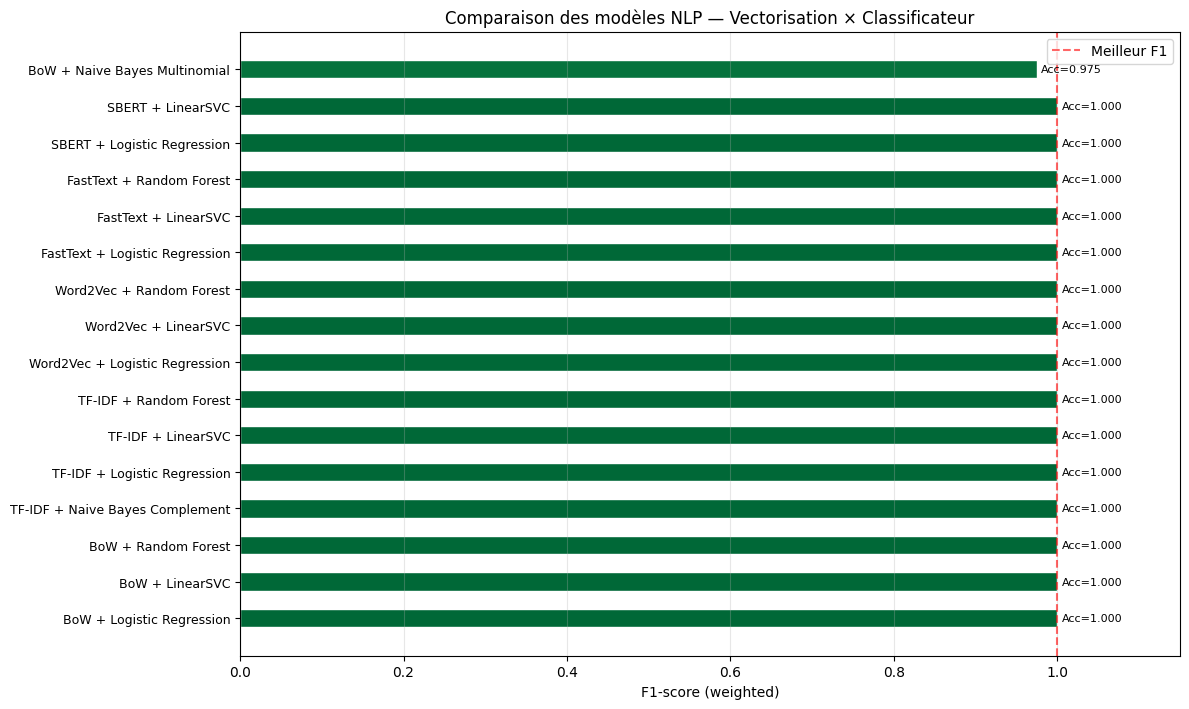


🏆 Meilleur modèle : BoW + Logistic Regression
   Accuracy   : 1.0000
   F1-weighted: 1.0000


In [16]:
df_res = pd.DataFrame(results).sort_values('F1-weighted', ascending=False)
print('=== RÉSUMÉ COMPARATIF ===')
display(df_res.round(4).reset_index(drop=True))

# ── Graphique comparatif ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, max(5, len(df_res)*0.45)))

y_pos = np.arange(len(df_res))
bars = ax.barh(y_pos, df_res['F1-weighted'], height=0.5,
               color=plt.cm.RdYlGn(df_res['F1-weighted']),
               edgecolor='white')

for bar, acc in zip(bars, df_res['Accuracy']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'Acc={acc:.3f}', va='center', fontsize=8)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_res['Modèle'], fontsize=9)
ax.set_xlabel('F1-score (weighted)')
ax.set_title('Comparaison des modèles NLP — Vectorisation × Classificateur')
ax.set_xlim(0, 1.15)
ax.axvline(x=df_res['F1-weighted'].max(), color='red',
           linestyle='--', alpha=0.6, label='Meilleur F1')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/nlp_comparison.png', dpi=120)
plt.show()

best_model = df_res.iloc[0]
print(f'\n🏆 Meilleur modèle : {best_model["Modèle"]}')
print(f'   Accuracy   : {best_model["Accuracy"]:.4f}')
print(f'   F1-weighted: {best_model["F1-weighted"]:.4f}')

## 🗂️ 8. Matrice de Confusion — Meilleur Modèle


Rapport de classification (TF-IDF + LinearSVC) :
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier       1.00      1.00      1.00       464
   Plastique       1.00      1.00      1.00       559
       Verre       1.00      1.00      1.00       517

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998



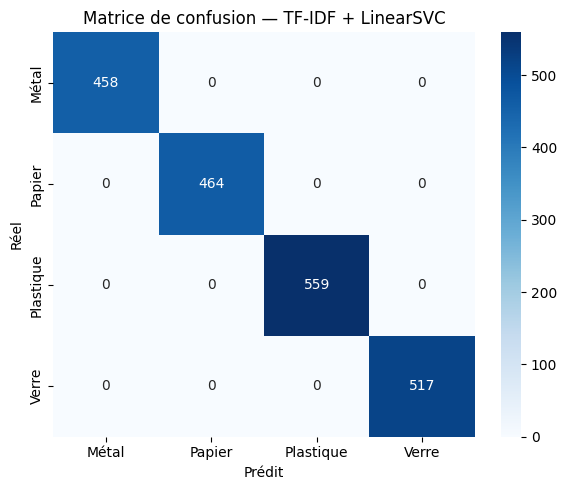

In [17]:
# TF-IDF + LinearSVC (généralement le meilleur)
final_clf = LinearSVC(C=1.0, max_iter=2000, random_state=SEED)
final_clf.fit(X_tfidf_train, y_train)
y_final_pred = final_clf.predict(X_tfidf_test)

print('Rapport de classification (TF-IDF + LinearSVC) :')
print(classification_report(y_test, y_final_pred, target_names=CLASSES))

plot_confusion(y_test, y_final_pred, CLASSES, 'Matrice de confusion — TF-IDF + LinearSVC')

## 💾 9. Sauvegarde


In [18]:
import pickle

# Sauvegarder le meilleur pipeline
best_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1,2),
                               sublinear_tf=True, min_df=2)),
    ('clf',   LinearSVC(C=1.0, max_iter=2000, random_state=SEED))
])
best_pipeline.fit(X_stem, y)   # entraîner sur tout le corpus

with open('outputs/nlp_best_pipeline.pkl', 'wb') as f:
    pickle.dump({'pipeline': best_pipeline, 'label_encoder': le}, f)

# Sauvegarder les résultats
df_res.to_csv('outputs/nlp_results.csv', index=False)

print('✅ Sauvegardés :')
print('   outputs/nlp_best_pipeline.pkl')
print('   outputs/nlp_results.csv')
print('   outputs/nlp_comparison.png')

# Test du pipeline sauvegardé
test_texts = [
    'Plaque en acier inoxydable très résistante à la corrosion',
    'Panneau de bois massif pour cuisine et ameublement',
    'Plastique recyclé haute densité léger et flexible',
]
test_processed = [preprocess(t, method='stem') for t in test_texts]
predictions    = le.inverse_transform(best_pipeline.predict(test_processed))
print('\nTest du pipeline :')
for text, pred in zip(test_texts, predictions):
    print(f'  [{pred:12s}]  {text[:55]}...')

✅ Sauvegardés :
   outputs/nlp_best_pipeline.pkl
   outputs/nlp_results.csv
   outputs/nlp_comparison.png

Test du pipeline :
  [Métal       ]  Plaque en acier inoxydable très résistante à la corrosi...
  [Papier      ]  Panneau de bois massif pour cuisine et ameublement...
  [Verre       ]  Plastique recyclé haute densité léger et flexible...
